In [1]:
get_ipython().run_line_magic('matplotlib', 'inline')
import sys, platform, json, importlib.metadata, torch
assert not torch.cuda.is_available(), 'CPU teaching lane unexpectedly sees CUDA'
identity = dict(executable=sys.executable, prefix=sys.prefix, python=platform.python_version(), platform=platform.platform(), cuda_available=torch.cuda.is_available(), torch_cuda_build=torch.version.cuda, packages={name:importlib.metadata.version(name) for name in ['torch','numpy','matplotlib','nbformat','nbclient','ipykernel','transformers','tokenizers','peft']})
print('__DONGXI_KERNEL_IDENTITY__:' + json.dumps(identity, sort_keys=True))

__DONGXI_KERNEL_IDENTITY__:{"cuda_available": false, "executable": "/tmp/dongxi-course-reproduction.ZfVaEu/venv/bin/python", "packages": {"ipykernel": "7.4.0", "matplotlib": "3.10.8", "nbclient": "0.11.0", "nbformat": "5.11.1", "numpy": "2.5.3", "peft": "0.20.0", "tokenizers": "0.23.2", "torch": "2.14.1+cpu", "transformers": "5.18.0"}, "platform": "Linux-6.17.0-1031-nvidia-aarch64-with-glibc2.39", "prefix": "/tmp/dongxi-course-reproduction.ZfVaEu/venv", "python": "3.12.14", "torch_cuda_build": null}


# Can the tiny model learn an answer and an ending?

Chapter 9 · Day 13

Run a bounded, reproducible symbolic SFT exercise. The starting model is random, not a pretrained language model. Four seen requests cannot establish broad transfer.

Use the cycle: prediction → inspect mechanism → change one choice → interpret limits. Runnable reference answers follow each question. All computations use CPU; no model download or server is started.

In [2]:
from pathlib import Path
import sys
root = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "src/dongxi_llms").is_dir())
sys.path.insert(0, str(root / "src"))
import math, copy, json
import numpy as np
import torch
import matplotlib.pyplot as plt
torch.set_num_threads(1)
plt.rcParams.update({"figure.facecolor": "white", "axes.facecolor": "white",
                     "font.family": "DejaVu Sans", "font.size": 11})
from dongxi_llms import evaluation_lab as ev
from dongxi_llms import instruction_data_lab as data
from dongxi_llms import sft_lab as sft
def show_flow(labels, focus):
    fig, ax = plt.subplots(figsize=(11, 1.9))
    for i, label in enumerate(labels):
        ax.text(i, .5, label, ha="center", va="center",
                bbox=dict(boxstyle="round,pad=.45", fc="#dce9f5" if i == focus else "#f6f6f6", ec="#666"))
        if i: ax.annotate("", (i-.25,.5), (i-.75,.5), arrowprops=dict(arrowstyle="->",color="#555"))
    ax.set_xlim(-.6,len(labels)-.4); ax.set_ylim(0,1); ax.axis("off")
    ax.set_title("Schematic process: highlighted component is this lesson's focus")
    plt.show()


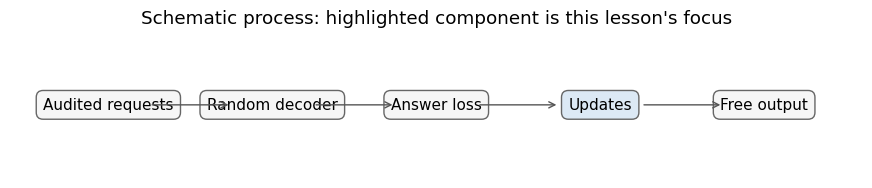

In [3]:
show_flow(["Audited requests","Random decoder","Answer loss","Updates","Free output"], 3)

**Saved reference preview — rerun the preceding plot cell for current inputs.**

![01 tiny assistant training: reference plot 01](../figures/chapter-09/day-13-01_tiny_assistant_training-01.png)

This fixed image comes from the CPU reference or the explicitly identified saved evidence; changing inputs does not update the preview automatically.

## Predict 1

Predict whether answer NLL and exact generated answer-plus-END agreement will move identically.

Pause and explain your reasoning before running the next cell.

### Reference answer and mechanism

Likelihood changes continuously; exact sequence agreement changes at discrete decoding boundaries. Both are useful, and neither establishes unseen-task generalization.

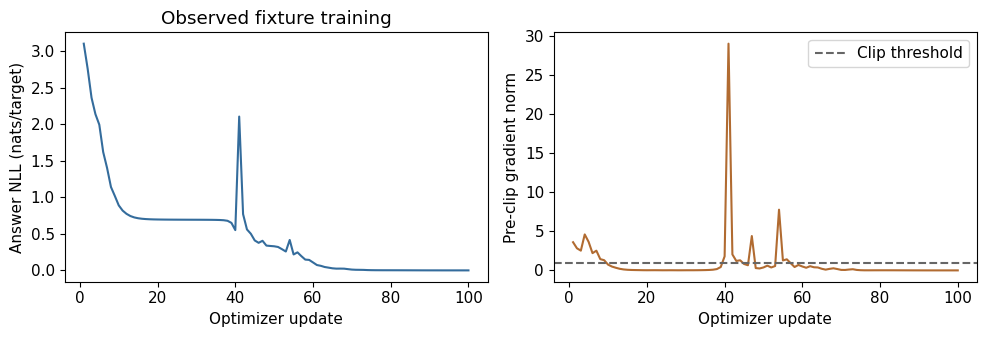

{'initial_loss': 3.1011672019958496, 'final_loss': 0.0005545320454984903, 'fixture_sequence_exact_match': 1.0, 'state_forward_replay_equal': True}


In [4]:
model,result=sft.bounded_run(100)
fig,axes=plt.subplots(1,2,figsize=(10,3.5))
axes[0].plot(np.arange(1,101),result["history"],color="#346c9c")
axes[0].set(xlabel="Optimizer update",ylabel="Answer NLL (nats/target)",title="Observed fixture training")
axes[1].plot(np.arange(1,101),result["gradient_norms"],color="#b16b31")
axes[1].axhline(1,color="#666",linestyle="--",label="Clip threshold")
axes[1].set(xlabel="Optimizer update",ylabel="Pre-clip gradient norm"); axes[1].legend()
plt.tight_layout(); plt.show()
print({k:result[k] for k in ("initial_loss","final_loss","fixture_sequence_exact_match","state_forward_replay_equal")})
assert result["final_loss"]<result["initial_loss"]

**Saved reference preview — rerun the preceding plot cell for current inputs.**

![01 tiny assistant training: reference plot 02](../figures/chapter-09/day-13-01_tiny_assistant_training-02.png)

This fixed image comes from the CPU reference or the explicitly identified saved evidence; changing inputs does not update the preview automatically.

## Predict 2

Inspect every fixed request rather than selecting a favorite. Did each produce the requested word and end marker?

Pause and explain your reasoning before running the next cell.

### Reference answer and mechanism

Compare raw IDs with the declared targets. Record mismatches rather than rewriting prompts or searching seeds.

In [5]:
for generated,expected in zip(result["outputs"],result["expected"]):
    print("Generated:",[data.ID_TO_WORD[x] for x in generated],"expected:",[data.ID_TO_WORD[x] for x in expected])
print("Measured fixture sequence EM:",result["fixture_sequence_exact_match"])

Generated: ['red', 'end'] expected: ['red', 'end']
Generated: ['blue', 'end'] expected: ['blue', 'end']
Generated: ['green', 'end'] expected: ['green', 'end']
Generated: ['yellow', 'end'] expected: ['yellow', 'end']
Measured fixture sequence EM: 1.0


## Predict 3

Can this experiment support 'SFT turned Qwen into a reliable assistant'?

Pause and explain your reasoning before running the next cell.

### Reference answer and mechanism

No. It uses a random tiny model and four known symbolic examples. It supports local optimization/alignment mechanics. The larger base-to-assistant specification requires pinned Qwen-Base and held-out instructions.

In [6]:
evidence={"observed":"loss and free completions on four seen symbolic copy prompts",
          "unestablished":["pretrained transfer","new phrasings","general factual reliability","Qwen results"]}
print(json.dumps(evidence,indent=2))

{
  "observed": "loss and free completions on four seen symbolic copy prompts",
  "unestablished": [
    "pretrained transfer",
    "new phrasings",
    "general factual reliability",
    "Qwen results"
  ]
}


## Reading the evidence

The figures are regenerated from the current lesson tensors or declared fixture. Axes and counts define the comparison. Change one control, rerun the relevant cell, and explain what changed in the mechanism. Separate a verified implementation property from a claim about a real language model.

Return to the corresponding chapter and worked solution for the complete argument.